# L2p8_m9: $N(M)$ and $N(z)$ for eight lightcones

Load `data/cnc/L2p8_m9_M500c_binned_multilc.npz` and plot the eight observer
binned counts separately:

- $N(M_{500c})$ in fixed $z$ slices
- $N(z)$ in fixed $M_{500c}$ slices

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 8,
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

DATA_NPZ = Path("/scratch/scratch-lxu/flamingo_repo/data/cnc/L2p8_m9_M500c_binned_multilc.npz")
N_OBS = 8
Z_SLICE_IDX = [2, 5, 8, 11]
M_SLICE_IDX = [1, 4, 7, 10]

data = np.load(DATA_NPZ)
counts_lc = data["counts_lc"]  # (8, n_z, n_M)
Z_EDGES = data["bins_edges_z"]
M_EDGES = data["bins_edges_M"]
M_CENT = np.sqrt(M_EDGES[:-1] * M_EDGES[1:])
Z_CENT = 0.5 * (Z_EDGES[:-1] + Z_EDGES[1:])
M_XLIM = (float(M_EDGES[0]), float(M_EDGES[-1]))
Z_XLIM = (float(Z_EDGES[0]), float(Z_EDGES[-1]))
LC_COLORS = plt.cm.tab10(np.linspace(0, 0.9, N_OBS))


def log_ylim_from_values(values: np.ndarray, *, floor: float = 0.8, ceil: float = 2.0) -> tuple[float, float]:
    pos = values[values > 0]
    if pos.size == 0:
        return 1.0, 10.0
    return float(pos.min()) * floor, float(pos.max()) * ceil


def observer_stats(counts_1d: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """counts_1d: (n_obs, n_bins) -> mean, std across observers, Poisson sqrt(mean)."""
    mean = counts_1d.mean(axis=0)
    # std = counts_1d.std(axis=0, ddof=1)
    std = counts_1d.std(axis=0, ddof=0)
    poisson = np.sqrt(np.maximum(mean, 0.0))
    return mean, std, poisson


def poisson_ratio(counts_1d: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    mean, std, poisson = observer_stats(counts_1d)
    ratio = np.full_like(mean, np.nan, dtype=float)
    ok = poisson > 0
    ratio[ok] = std[ok] / poisson[ok]
    return mean, std, poisson, ratio


print(f"loaded {DATA_NPZ.name}: counts_lc {counts_lc.shape}")

loaded L2p8_m9_M500c_binned_multilc.npz: counts_lc (8, 15, 12)


## $N(M_{500c})$ at fixed $z$

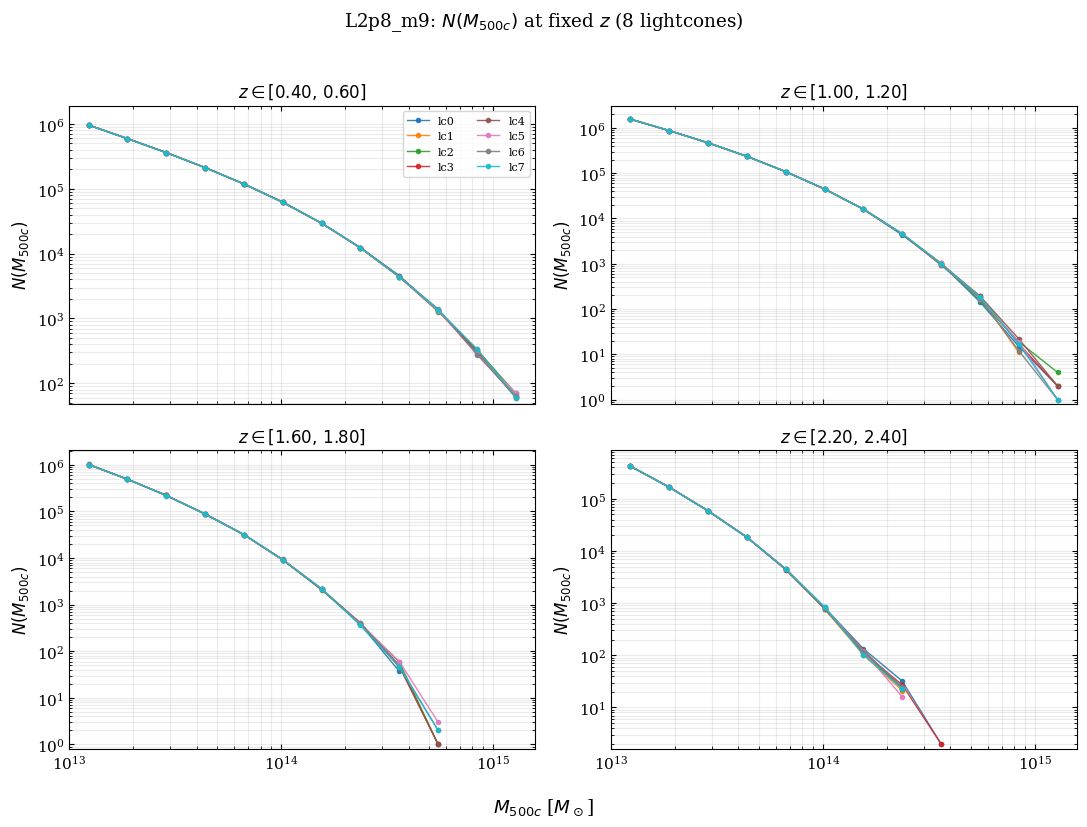

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
for ax, zi in zip(axes.ravel(), Z_SLICE_IDX):
    z_lo, z_hi = Z_EDGES[zi], Z_EDGES[zi + 1]
    slice_counts = counts_lc[:, zi, :]
    for obs in range(N_OBS):
        n_m = slice_counts[obs]
        mask = n_m > 0
        ax.plot(
            M_CENT[mask], n_m[mask], "o-", ms=3, lw=1,
            color=LC_COLORS[obs], label=f"lc{obs}", alpha=0.9,
        )
    ax.set_xscale("log")
    ax.set_xlim(M_XLIM)
    ax.set_yscale("log")
    ax.set_ylim(log_ylim_from_values(slice_counts))
    ax.set_title(rf"$z \in [{z_lo:.2f},\,{z_hi:.2f}]$")
    ax.set_ylabel(r"$N(M_{500c})$")
    ax.grid(True, which="both", alpha=0.25)
fig.supxlabel(r"$M_{500c}$ [$M_\odot$]")
axes[0, 0].legend(loc="upper right", ncol=2)
fig.suptitle(r"L2p8_m9: $N(M_{500c})$ at fixed $z$ (8 lightcones)", y=1.02)
fig.tight_layout()
plt.show()

## $N(z)$ at fixed $M_{500c}$

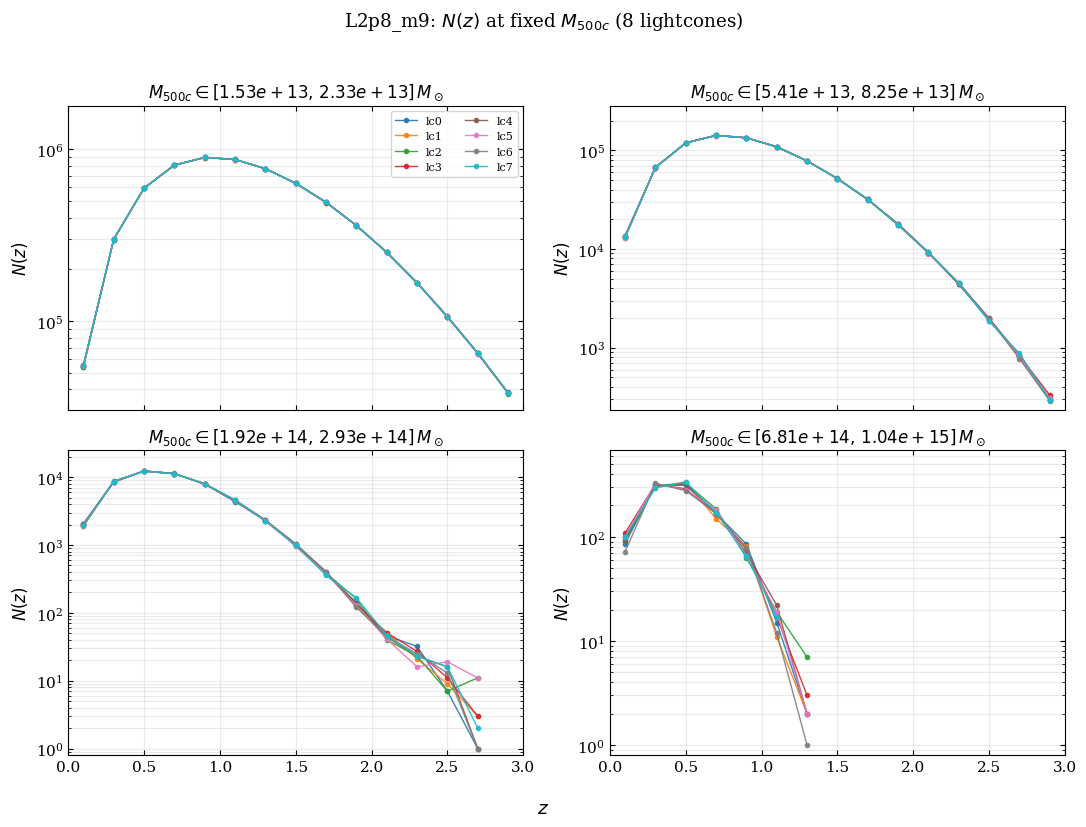

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
for ax, mi in zip(axes.ravel(), M_SLICE_IDX):
    m_lo, m_hi = M_EDGES[mi], M_EDGES[mi + 1]
    slice_counts = counts_lc[:, :, mi]
    for obs in range(N_OBS):
        n_z = slice_counts[obs]
        mask = n_z > 0
        ax.plot(
            Z_CENT[mask], n_z[mask], "o-", ms=3, lw=1,
            color=LC_COLORS[obs], label=f"lc{obs}", alpha=0.9,
        )
    ax.set_xlim(Z_XLIM)
    ax.set_yscale("log")
    ax.set_ylim(log_ylim_from_values(slice_counts))
    ax.set_title(rf"$M_{{500c}} \in [{m_lo:.2e},\,{m_hi:.2e}]\,M_\odot$")
    ax.set_ylabel(r"$N(z)$")
    ax.grid(True, which="both", alpha=0.25)
fig.supxlabel(r"$z$")
axes[0, 0].legend(loc="upper right", ncol=2)
fig.suptitle(r"L2p8_m9: $N(z)$ at fixed $M_{500c}$ (8 lightcones)", y=1.02)
fig.tight_layout()
plt.show()

## Poisson check: $\sigma(N) / \sqrt{\langle N \rangle}$

At each bin, $\sigma(N)$ is the sample std over the eight lightcones and
$\sqrt{\langle N \rangle}$ is the Poisson expectation from the mean count.
Ratio $\approx 1$ means observer scatter is consistent with shot noise.

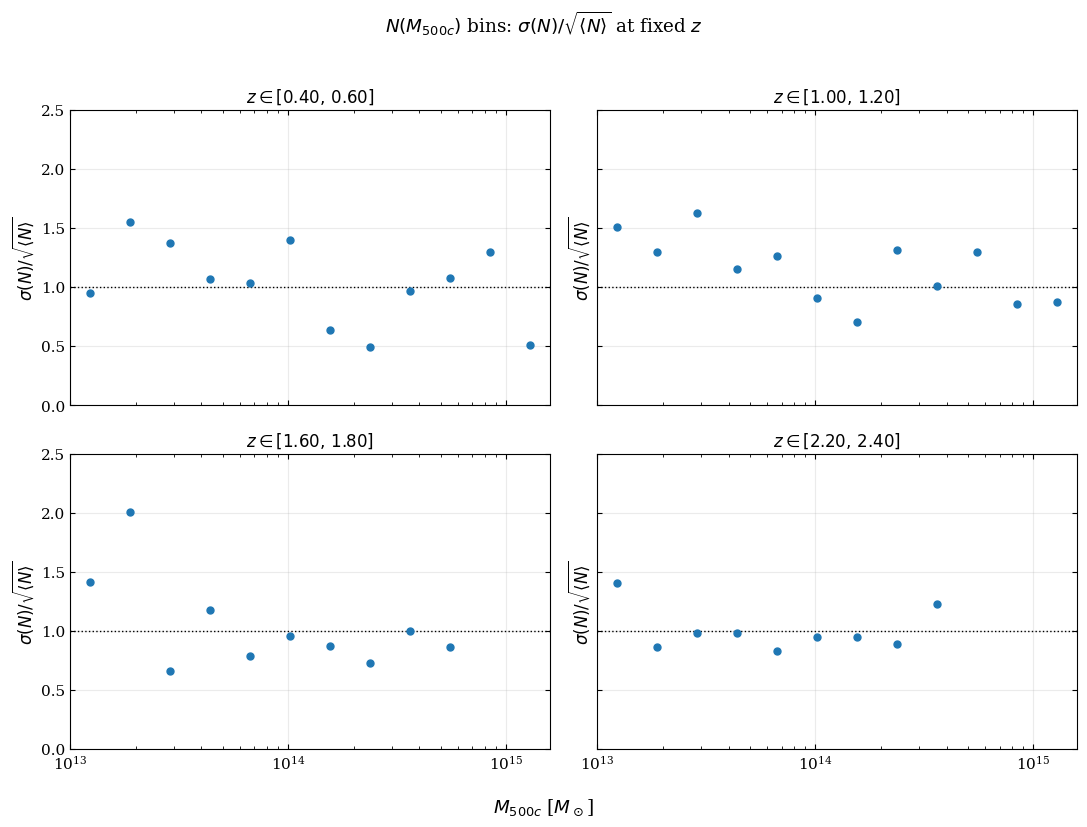

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
for ax, zi in zip(axes.ravel(), Z_SLICE_IDX):
    z_lo, z_hi = Z_EDGES[zi], Z_EDGES[zi + 1]
    mean, std, poisson, ratio = poisson_ratio(counts_lc[:, zi, :])
    ok = np.isfinite(ratio)
    ax.axhline(1.0, color="k", ls=":", lw=1)
    ax.plot(M_CENT[ok], ratio[ok], "o", ms=5, mfc="C0", mec="C0")
    ax.set_xscale("log")
    ax.set_xlim(M_XLIM)
    ax.set_ylim(0, 2.5)
    ax.set_title(rf"$z \in [{z_lo:.2f},\,{z_hi:.2f}]$")
    ax.set_ylabel(r"$\sigma(N) / \sqrt{\langle N \rangle}$")
    ax.grid(True, alpha=0.25)
fig.supxlabel(r"$M_{500c}$ [$M_\odot$]")
fig.suptitle(r"$N(M_{500c})$ bins: $\sigma(N) / \sqrt{\langle N \rangle}$ at fixed $z$", y=1.02)
fig.tight_layout()
plt.show()

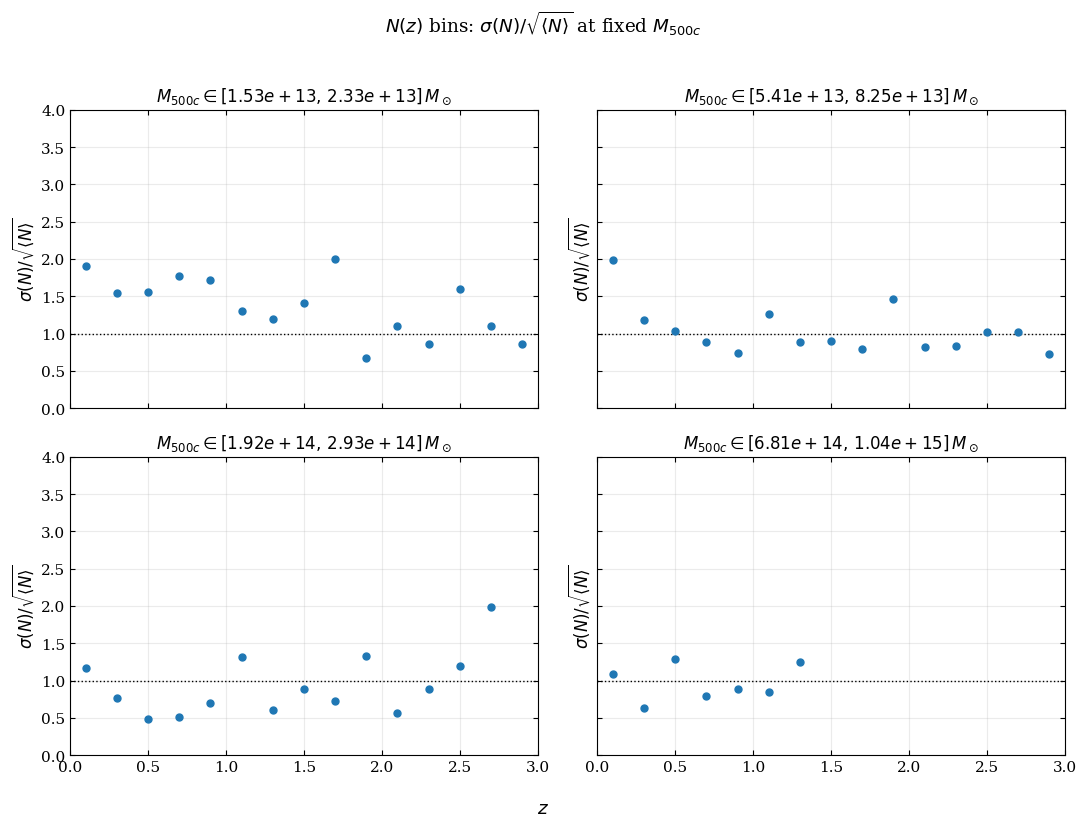

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
for ax, mi in zip(axes.ravel(), M_SLICE_IDX):
    m_lo, m_hi = M_EDGES[mi], M_EDGES[mi + 1]
    mean, std, poisson, ratio = poisson_ratio(counts_lc[:, :, mi])
    ok = np.isfinite(ratio)
    ax.axhline(1.0, color="k", ls=":", lw=1)
    ax.plot(Z_CENT[ok], ratio[ok], "o", ms=5, mfc="C0", mec="C0")
    ax.set_xlim(Z_XLIM)
    ax.set_ylim(0, 4)
    ax.set_title(rf"$M_{{500c}} \in [{m_lo:.2e},\,{m_hi:.2e}]\,M_\odot$")
    ax.set_ylabel(r"$\sigma(N) / \sqrt{\langle N \rangle}$")
    ax.grid(True, alpha=0.25)
fig.supxlabel(r"$z$")
fig.suptitle(r"$N(z)$ bins: $\sigma(N) / \sqrt{\langle N \rangle}$ at fixed $M_{500c}$", y=1.02)
fig.tight_layout()
plt.show()

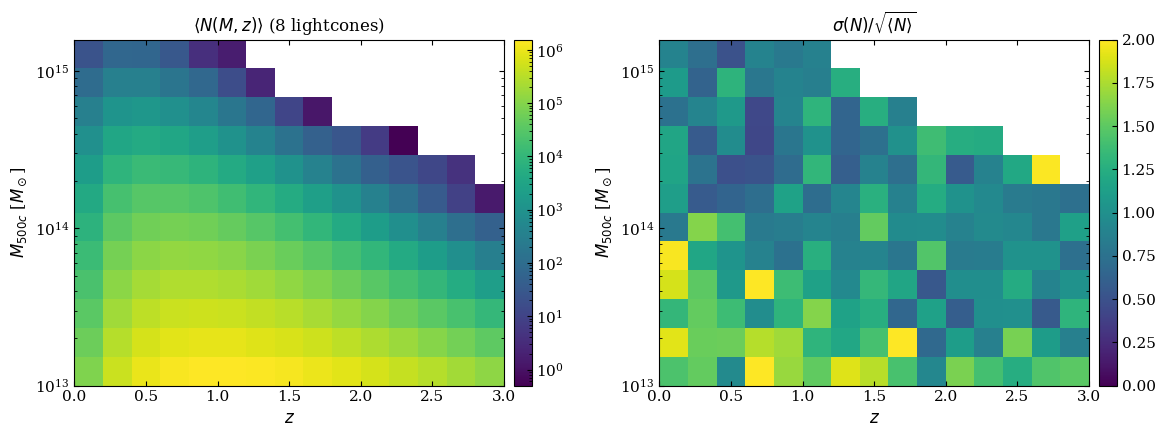

In [6]:
mean_2d = counts_lc.mean(axis=0)
# std_2d = counts_lc.std(axis=0, ddof=1)
std_2d = counts_lc.std(axis=0, ddof=0)
poisson_2d = np.sqrt(np.maximum(mean_2d, 0.0))
ratio_2d = np.divide(std_2d, poisson_2d, out=np.full_like(std_2d, np.nan), where=poisson_2d > 0)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4.5))
im0 = ax0.pcolormesh(Z_EDGES, M_EDGES, mean_2d.T, norm=plt.matplotlib.colors.LogNorm())
ax0.set_yscale("log")
ax0.set_xlim(Z_XLIM)
ax0.set_ylim(M_XLIM)
ax0.set_xlabel(r"$z$")
ax0.set_ylabel(r"$M_{500c}$ [$M_\odot$]")
ax0.set_title(r"$\langle N(M,z) \rangle$ (8 lightcones)")
fig.colorbar(im0, ax=ax0, pad=0.02)

im1 = ax1.pcolormesh(Z_EDGES, M_EDGES, ratio_2d.T, vmin=0, vmax=2)
ax1.set_yscale("log")
ax1.set_xlim(Z_XLIM)
ax1.set_ylim(M_XLIM)
ax1.set_xlabel(r"$z$")
ax1.set_ylabel(r"$M_{500c}$ [$M_\odot$]")
ax1.set_title(r"$\sigma(N) / \sqrt{\langle N \rangle}$")
fig.colorbar(im1, ax=ax1, pad=0.02)
fig.tight_layout()
plt.show()